In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [2]:
bd_quimb=24
bd_aer=24
mw=5

files = [
    f"mps_{bd_quimb}_eval_time.json",
    f"mpsaer_{bd_aer}_eval_time.json",
    f"pp_{mw}_eval_time.json"
]

legend_labels = [
    f"MPS(max bond dim={bd_quimb})",
    f"MPSAer(max bond dim={bd_aer})",
    f"PP(max weight={mw})"
]

markers = ["P", "s", "v"]

subplot_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]

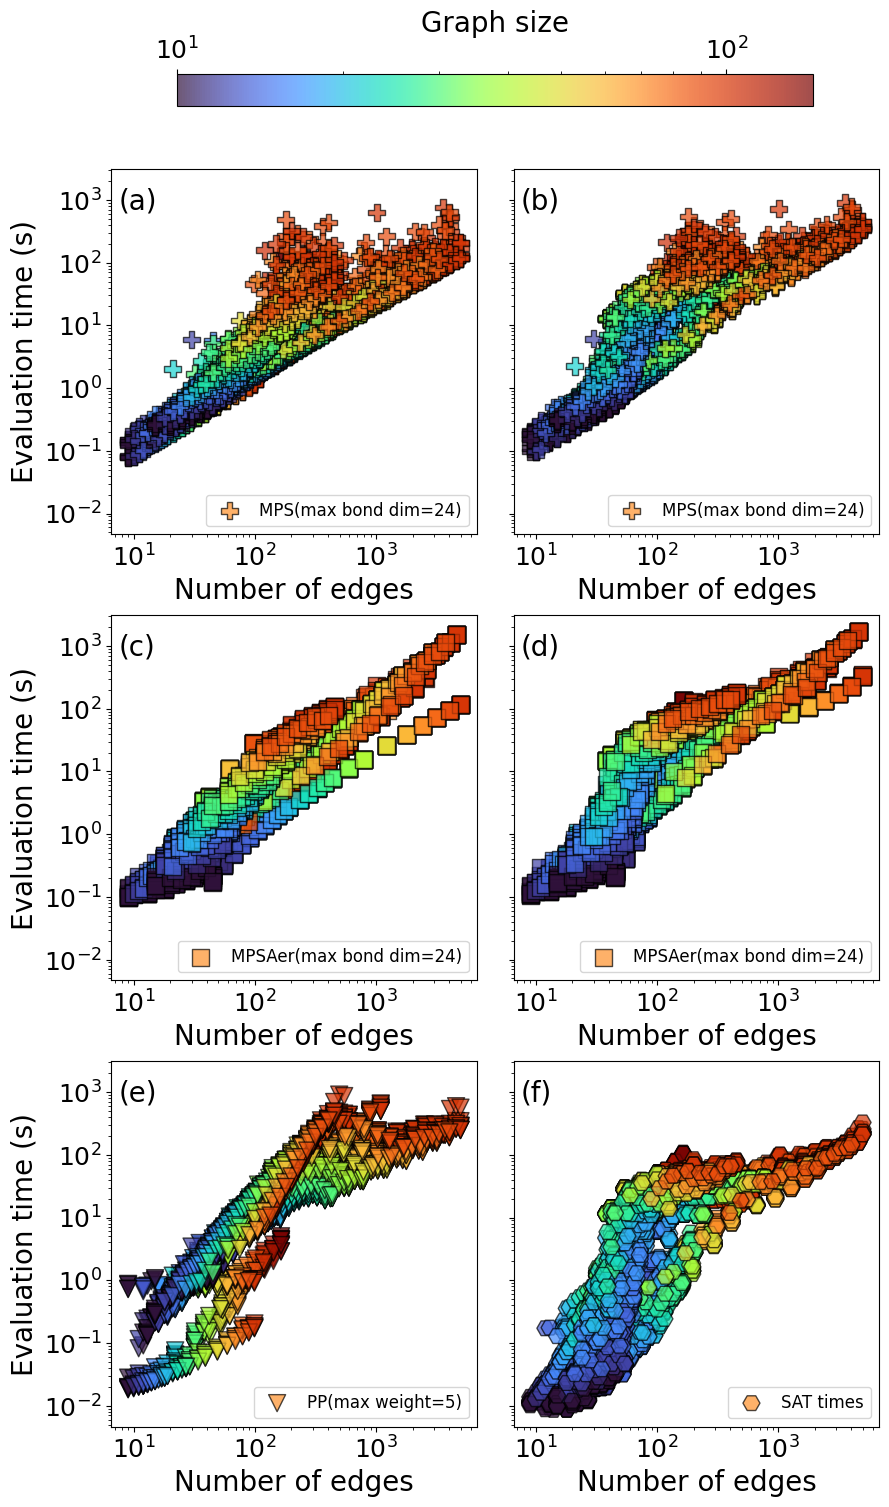

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(9, 15), sharey=True, constrained_layout=True)
sc = None

topology_patterns= ["heavyhex", "erdosrenyi", "regular", "swap"]

for i, file, legend, marker in zip(range(2), files, legend_labels, markers):
    
    with open(f"data/evaluation_times/{file}") as f:
        data = json.load(f)
        
    filtered_data = [
        v for k, v in data["results"].items()
        if any(p in k for p in topology_patterns)
    ]
    num_nodes = [v["num_nodes"] for v in filtered_data]
    num_edges = [v["num_edges"] for v in filtered_data]
    durations = [v["duration"] for v in filtered_data]
    sat_times = [v["SAT mapping time"] for v in filtered_data]

    norm = LogNorm(vmin=min(num_nodes), vmax=max(num_nodes))
    
    sc = axes[i][0].scatter(
        num_edges,
        durations,
        c=num_nodes,
        cmap="turbo",
        norm=norm,
        marker=marker,
        alpha=0.7,
        edgecolors="k",
        s=150,
        label=legend
    )
    axes[i][0].legend(loc="lower right",fontsize=12)
    axes[i][0].set_ylabel("Evaluation time (s)", fontsize=20)
    sc = axes[i][1].scatter(
        num_edges,
        np.array(durations)+ np.array(sat_times),
        c=num_nodes,
        cmap="turbo",
        norm=norm,
        marker=marker,
        alpha=0.7,
        edgecolors="k",
        s=150,
        label=legend
    )
    axes[i][1].legend(loc="lower right",fontsize=12)
    
with open(f"data/evaluation_times/{files[2]}") as f:
        data = json.load(f)
    
filtered_data = [
        v for k, v in data["results"].items()
        if any(p in k for p in topology_patterns)
    ]     
num_nodes = [v["num_nodes"] for v in filtered_data]
num_edges = [v["num_edges"] for v in filtered_data]
durations = [v["duration"] for v in filtered_data]
sat_times = [v["SAT mapping time"] for v in filtered_data]

axes[2][0].scatter(
    num_edges,
    durations,
    c=num_nodes,
    cmap="turbo",
    norm=norm,
    marker='v',
    alpha=0.7,
    edgecolors="k",
    s=150,
    label=legend_labels[2]
)
axes[2][0].legend(loc="lower right",fontsize=12)
axes[2][0].set_ylabel("Evaluation time (s)", fontsize=20)
axes[2][1].scatter(
    num_edges,
    sat_times,
    c=num_nodes,
    cmap="turbo",
    norm=norm,
    marker='H',
    alpha=0.7,
    edgecolors="k",
    s=150,
    label="SAT times"
)
axes[2][1].legend(loc="lower right",fontsize=12)

for ax, label in zip(axes.flatten(), subplot_labels):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_box_aspect(1)
    ax.set_xlabel("Number of edges", fontsize=20)
    ax.tick_params(axis="both", labelsize=18)
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left"
    )
    

cbar = fig.colorbar(sc, ax=axes, location="top", shrink=0.8)
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Graph size", fontsize=20)

plt.show()
fig.savefig(f"{bd_quimb}_{bd_aer}_{mw}_eval_time_num_edges.pdf", bbox_inches="tight")

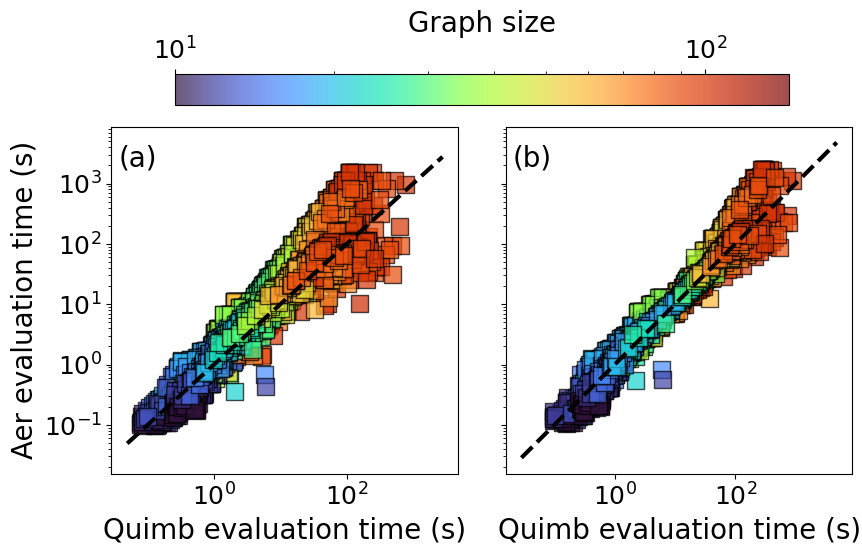

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5), sharey=True)
sc = None
colors =["blue", "orange"]
topology_patterns= ["heavyhex", "erdosrenyi", "regular", "swap"]
for i, file, legend, marker in zip(range(2), files, legend_labels, markers):
    
    with open(f"data/evaluation_times/{file}") as f:
        data = json.load(f)
        
    filtered_data = [
        v for k, v in data["results"].items()
        if any(p in k for p in topology_patterns)
    ]
    num_nodes = [v["num_nodes"] for v in filtered_data]
    durations[i] = [v["duration"] for v in filtered_data]
    sat_times[i] = [v["SAT mapping time"] for v in filtered_data]

norm = LogNorm(vmin=min(num_nodes), vmax=max(num_nodes))

sc = axes[0].scatter(
    durations[0],
    durations[1],
    c=num_nodes,
    cmap="turbo",
    norm=norm,
    edgecolors="k",
    marker=marker,
    alpha=0.7,
    s=150,
)

axes[0].set_ylabel("Aer evaluation time (s)", fontsize=20)
sc = axes[1].scatter(
    np.array(durations[0])+ np.array(sat_times[0]),
    np.array(durations[1])+ np.array(sat_times[1]),
    c=num_nodes,
    cmap="turbo",
    norm=norm,
    facecolors='none',
    edgecolors="k",
    marker=marker,
    alpha=0.7,
    s=150,
)
# axes[0].legend(loc="lower right",fontsize=12)
# axes[1].legend(loc="lower right",fontsize=12)
for ax, label in zip(axes.flatten(), subplot_labels):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_box_aspect(1)
    ax.set_xlabel("Quimb evaluation time (s)", fontsize=20)
    ax.tick_params(axis="both", labelsize=18)
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,
        fontsize=20,
        va="top",
        ha="left"
    )
    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    low = min(xmin, ymin)
    high = max(xmax, ymax)

    ax.plot(
        [low, high],
        [low, high],

        linestyle="--",

        color="k",

        linewidth=3,

        alpha=1,

        zorder=10,
    )
plt.tight_layout()
cbar = fig.colorbar(sc, ax=axes, location="top", shrink=0.8)
cbar.ax.tick_params(labelsize=18)
cbar.set_label("Graph size", fontsize=20)


plt.show()
fig.savefig(f"{bd_quimb}_{bd_aer}_eval_time_num_edges.pdf", bbox_inches="tight")